### Set up Hugging Face Token (Optional, but Recommended)

To remove the warning about `HF_TOKEN` and potentially get better performance/access to certain models, you can set your Hugging Face token securely in Colab secrets.

1.  Go to your Hugging Face profile and generate an access token.
2.  In Colab, click the '🔑 Secrets' icon in the left sidebar.
3.  Click 'Add new secret', name it `HF_TOKEN`, and paste your token.
4.  Ensure 'Notebook access' is enabled for this secret.

In [ ]:
#importing Libaries
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Download latest version
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
print(df.head())


Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']
   id    Season       city        date                        team1  \
0   1  IPL-2017  Hyderabad  05-04-2017          Sunrisers Hyderabad   
1   2  IPL-2017       Pune  06-04-2017               Mumbai Indians   
2   3  IPL-2017     Rajkot  07-04-2017                Gujarat Lions   
3   4  IPL-2017     Indore  08-04-2017       Rising Pune Supergiant   
4   5  IPL-2017  Bangalore  08-04-2017  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         f

In [ ]:
import kagglehub
import os
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
#datset overview
print(df.info())
print(df.head(5))
print(df.tail())
print(df.describe())
print( df["win_by_wickets"].astype(str))

Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  75

In [ ]:
import kagglehub
import os
import pandas as pd
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
# Count missing values in each column
df.isnull().sum()
df.fillna({
    "city": df["city"].mode()[0],
    "winner": df["winner"].mode()[0],
    "player_of_match": df["player_of_match"].mode()[0],
    "umpire1": df["umpire1"].mode()[0],
    "umpire2": df["umpire2"].mode()[0],
    "umpire3": df["umpire3"].mode()[0]
}, inplace=True)
print(df.duplicated().sum())

Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']
0


Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']


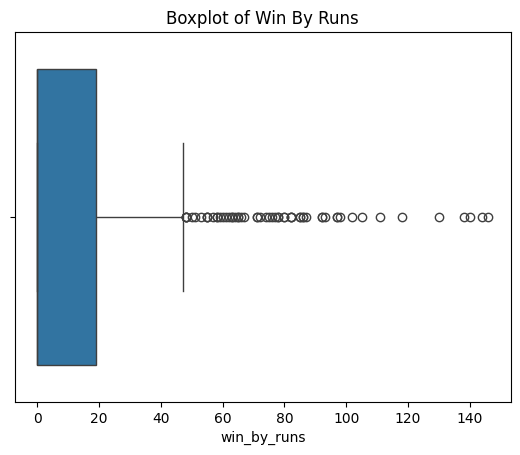

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
#boxplot using on single numercial colums
sns.boxplot(x=df["win_by_runs"])
plt.title("Boxplot of Win By Runs")
plt.show()

Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']


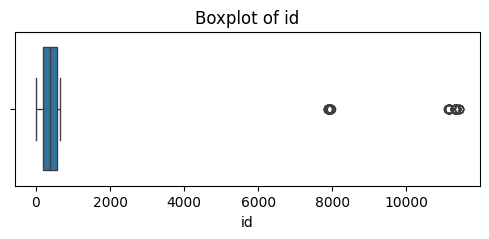

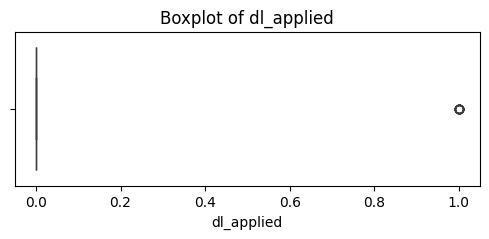

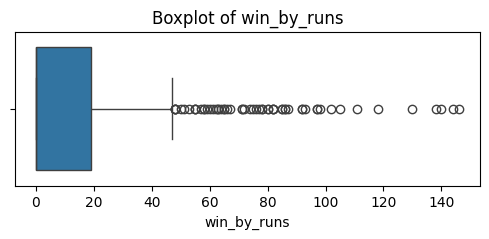

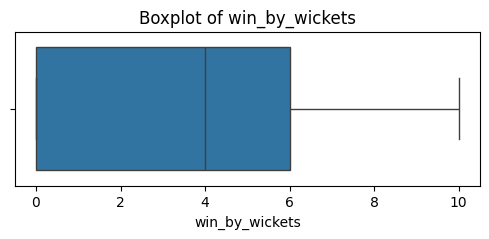

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
num_cols = df.select_dtypes(include=['int64']).columns
#boxlot using of multple columms numerical
#decting outlier
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy.stats import zscore
import pandas as pd
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)

df["z_score"] = zscore(df["win_by_runs"])

outliers = df[(df["z_score"] > 3) | (df["z_score"] < -3)]

print(outliers)
#remove outlier
dff = df[(df["z_score"] <= 3) & (df["z_score"] >= -3)]

print(dff.drop("z_score", axis=1, inplace=True))

Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']
        id    Season            city        date                        team1  \
8        9  IPL-2017            Pune  11-04-2017             Delhi Daredevils   
43      44  IPL-2017           Delhi  06-05-2017               Mumbai Indians   
59      60  IPL-2008       Bangalore  18-04-2008        Kolkata Knight Riders   
114    115  IPL-2008          Mumbai  30-05-2008             Rajasthan Royals   
121    122  IPL-2009  Port Elizabeth  20-04-2009          Chennai Super Kings   
131    132  IPL-2009  Port Elizabeth  27-04-2009               Mumbai Indians   
182    183  IPL-2010           Delhi  17-03-2010               Mumbai Indians   
279    280  IPL-2011       Bangalore  06-05-2011  Royal Challengers Bangalore   
295    296  IPL-2011      Dharamsala  17-05-2011              Kings XI Punj

/tmp/ipykernel_3585/1002711186.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  print(dff.drop("z_score", axis=1, inplace=True))


Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']


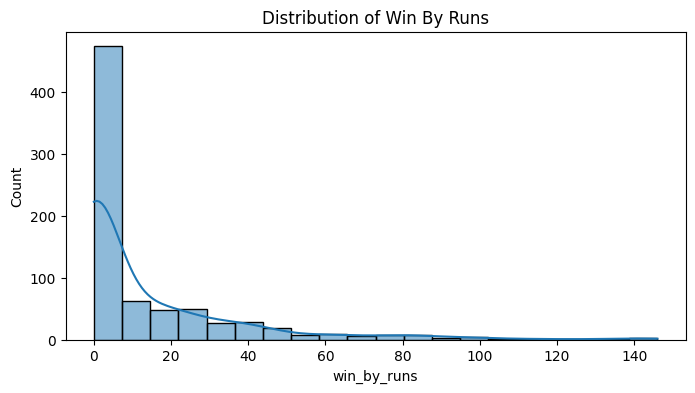

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy.stats import zscore
import pandas as pd
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
# Univariate Analysis
plt.figure(figsize=(8,4))
sns.histplot(df["win_by_runs"], bins=20, kde=True)
plt.title("Distribution of Win By Runs")
plt.show()

Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']


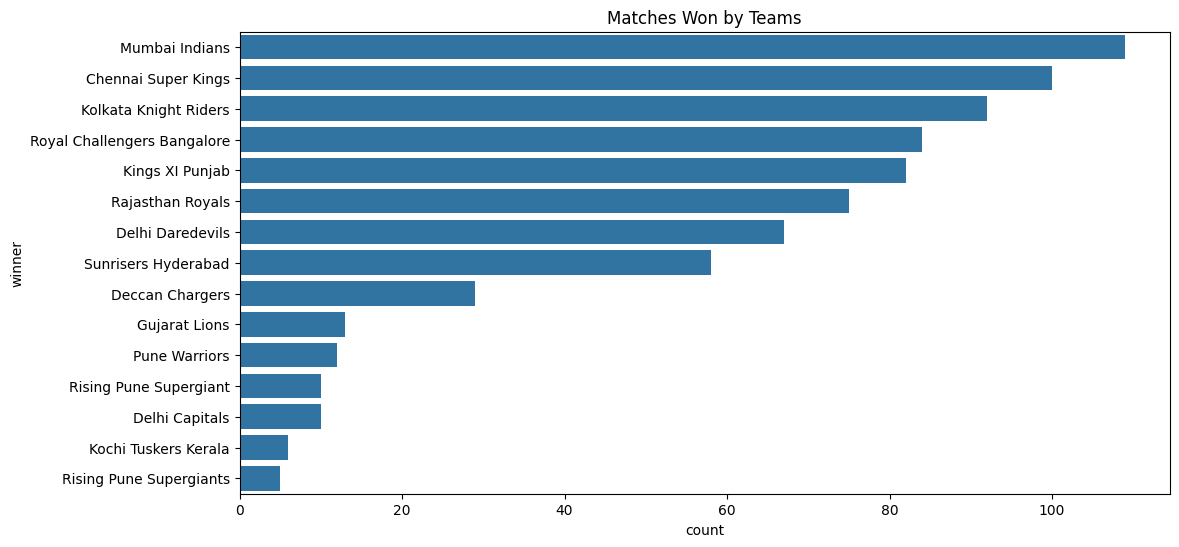

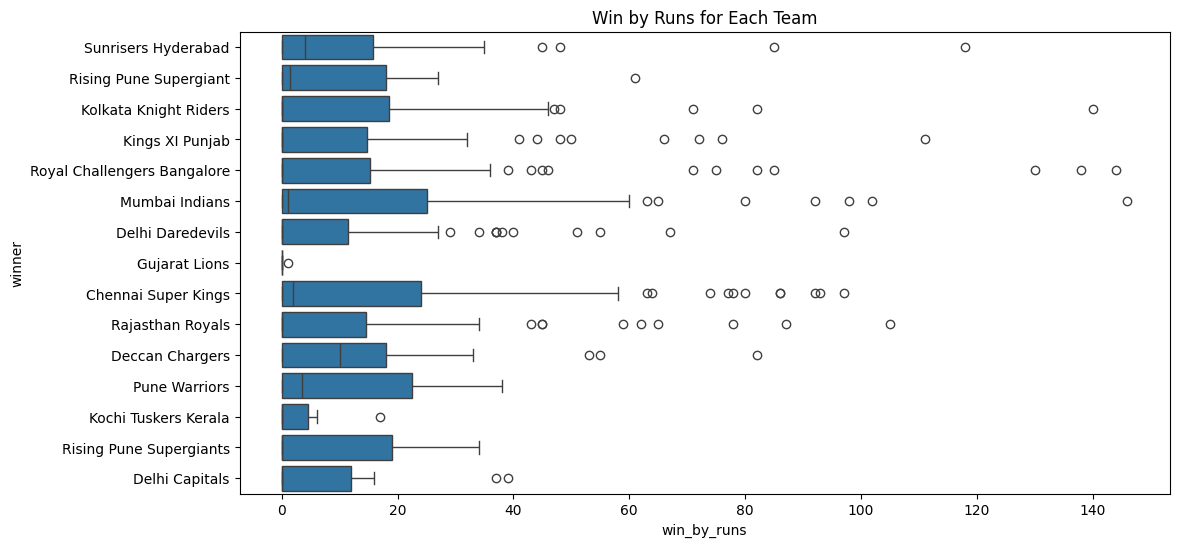

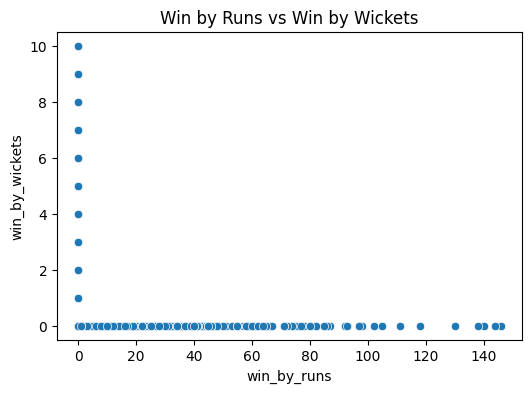

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy.stats import zscore
import pandas as pd
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
print(os.listdir(path))
#Bivariate analysis
file_path = os.path.join(path,"matches.csv")
 # Categorical vs Categorical
plt.figure(figsize=(12,6))
sns.countplot(y=df["winner"], order=df["winner"].value_counts().index)
plt.title("Matches Won by Teams")
plt.show()
# Categorical vs Numeric
plt.figure(figsize=(12,6))
sns.boxplot(x=df["win_by_runs"], y=df["winner"])
plt.title("Win by Runs for Each Team")
plt.show()
#  Numeric vs  Numeric
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["win_by_runs"], y=df["win_by_wickets"])
plt.title("Win by Runs vs Win by Wickets")
plt.show()

In [ ]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Using Colab cache for faster access to the 'ipl-data-set' dataset.
['matches.csv', 'teamwise_home_and_away.csv', 'deliveries.csv', 'most_runs_average_strikerate.csv', 'teams.csv', 'Players.xlsx']


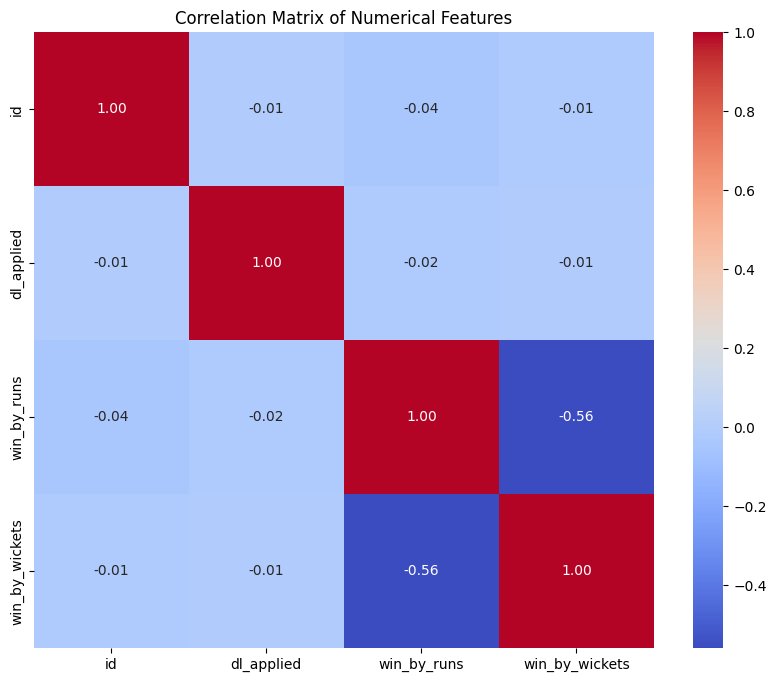

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import numpy as np
import pandas as pd
#coreelation analysis
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
print(os.listdir(path))
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import numpy as np
import pandas as pd
# features Engineering
path = kagglehub.dataset_download("ramjidoolla/ipl-data-set")
file_path = os.path.join(path,"matches.csv")
df = pd.read_csv(file_path)
df["match_dominance"] = df["win_by_runs"] + df["win_by_wickets"]
print(df["match_dominance"]
      )
df["is_close_match"] = np.where(
    (df["win_by_runs"] <= 10) & (df["win_by_wickets"] <= 2),
    1,
    0
)
print(df["is_close_match"])
df["win_type"] = np.where(
    df["win_by_runs"] > 0,
    "Runs",
    "Wickets"
)
print(df["win_type"])

Using Colab cache for faster access to the 'ipl-data-set' dataset.
0      35
1       7
2      10
3       6
4      15
       ..
751     9
752     6
753     2
754     6
755     1
Name: match_dominance, Length: 756, dtype: int64
0      0
1      0
2      0
3      0
4      0
      ..
751    0
752    0
753    1
754    0
755    1
Name: is_close_match, Length: 756, dtype: int64
0         Runs
1      Wickets
2      Wickets
3      Wickets
4         Runs
        ...   
751    Wickets
752    Wickets
753    Wickets
754    Wickets
755       Runs
Name: win_type, Length: 756, dtype: object


In [ ]:
!pip install mlflow
import mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [ ]:
mlflow.set_experiment("IPL Match Analysis Experiment")

with mlflow.start_run():
    # Your ML code and logging will go here
    mlflow.log_param("example_param", "value")
    mlflow.log_metric("example_metric", 0.95)

print("MLflow experiment initialized and an example run completed.")

2026/07/03 09:22:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/03 09:22:33 INFO mlflow.store.db.utils: Updating database tables
2026/07/03 09:22:38 INFO mlflow.tracking.fluent: Experiment with name 'IPL Match Analysis Experiment' does not exist. Creating a new experiment.


MLflow experiment initialized and an example run completed.


This code sets up an experiment named `IPL Match Analysis Experiment` and then starts a run within it. You can place your model training, evaluation, and logging code inside the `with mlflow.start_run():` block. I've included example `mlflow.log_param` and `mlflow.log_metric` calls to illustrate how you would record information about your runs.

In [ ]:
# Install other commonly used machine learning packages
!pip install scikit-learn xgboost